# 03 — Modelo de Machine Learning

Dois modelos complementares:

- **Modelo A** — Random Forest para prever IRR dado um cenário de objetos
- **Modelo B** — Regressão polinomial para projetar crescimento de objetos até 2035

### Resultado final
Curva de **risco projetado por faixa de altitude até 2035**.

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

sns.set_theme(style='darkgrid', palette='tab10')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 110

RAW_DIR  = Path('../data/raw')
PROC_DIR = Path('../data/processed')
OUT_DIR  = Path('../outputs')

print('Imports OK')

Imports OK


## 1. Carregar os Dados

In [2]:
df = pd.read_csv(PROC_DIR / 'features_risco_leo.csv')

satcat = pd.read_csv(RAW_DIR / 'satcat.csv', low_memory=False)
satcat['LAUNCH'] = pd.to_datetime(satcat['LAUNCH'], errors='coerce')
satcat['LAUNCH_YEAR'] = satcat['LAUNCH'].dt.year

print(f'Features LEO: {df.shape}')
print(f'Satcat: {len(satcat):,} objetos')
print(f'\nFaixas: {df["FAIXA_ALT"].tolist()}')

Features LEO: (18, 22)
Satcat: 68,467 objetos

Faixas: ['200-300', '300-400', '400-500', '500-600', '600-700', '700-800', '800-900', '900-1000', '1000-1100', '1100-1200', '1200-1300', '1300-1400', '1400-1500', '1500-1600', '1600-1700', '1700-1800', '1800-1900', '1900-2000']


## 2. Modelo A — Random Forest para prever IRR

### 2.1 Preparação

Temos 18 faixas (dataset pequeno), então usamos **Leave-One-Out CV** — a estratégia correta para datasets pequenos.

In [3]:
FEATURES = [
    'alt_min',
    'n_total',
    'n_debris',
    'n_payload',
    'prop_perigoso',
    'densidade_por_km3',
    'incl_media',
    'volume_km3',
]
TARGET = 'IRR'

X = df[FEATURES].copy().fillna(df[FEATURES].median())
y = df[TARGET].copy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nEstatisticas do IRR:')
print(y.describe().round(2))

X shape: (18, 8)
y shape: (18,)

Estatisticas do IRR:
count    18.00
mean      4.23
std       1.32
min       1.43
25%       3.84
50%       4.28
75%       4.80
max       6.80
Name: IRR, dtype: float64


### 2.2 Comparar modelos com LOO-CV

In [4]:
modelos = {
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42, max_depth=4),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=3),
    'Regressao Linear':  LinearRegression(),
}

loo = LeaveOneOut()
resultados = {}

for nome, modelo in modelos.items():
    rmse_scores = np.sqrt(-cross_val_score(modelo, X, y, cv=loo, scoring='neg_mean_squared_error'))
    r2_scores   = cross_val_score(modelo, X, y, cv=loo, scoring='r2')
    resultados[nome] = {'RMSE': rmse_scores.mean(), 'RMSE_std': rmse_scores.std(), 'R2': r2_scores.mean()}
    print(f'{nome:25s} | RMSE: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f} | R2: {r2_scores.mean():.3f}')

melhor = min(resultados, key=lambda k: resultados[k]['RMSE'])
print(f'\nMelhor modelo (menor RMSE): {melhor}')

Random Forest             | RMSE: 0.722 +/- 0.581 | R2: nan
Gradient Boosting         | RMSE: 0.544 +/- 0.694 | R2: nan
Regressao Linear          | RMSE: 0.033 +/- 0.032 | R2: nan

Melhor modelo (menor RMSE): Regressao Linear


### 2.3 Treinar modelo final e avaliar

Metricas no treino completo:
  RMSE : 0.3339
  MAE  : 0.2845
  R2   : 0.9326


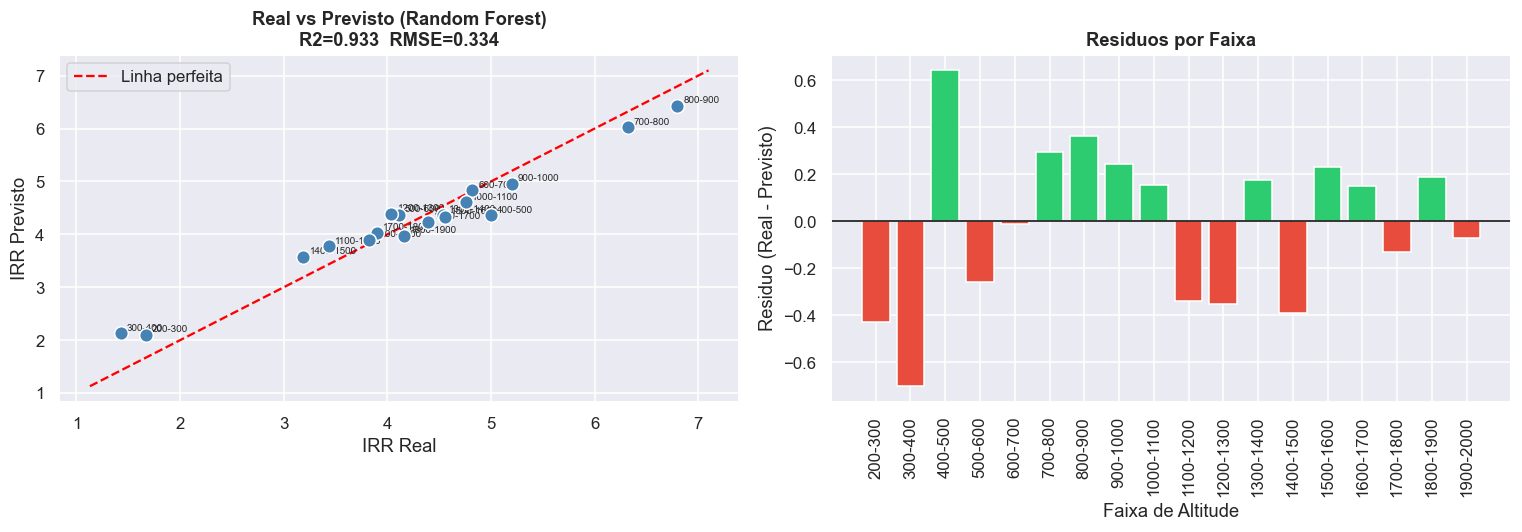

In [5]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=4)
rf.fit(X, y)
y_pred = rf.predict(X)

rmse = np.sqrt(mean_squared_error(y, y_pred))
mae  = mean_absolute_error(y, y_pred)
r2   = r2_score(y, y_pred)

print(f'Metricas no treino completo:')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  R2   : {r2:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y, y_pred, color='steelblue', edgecolors='white', s=80, zorder=5)
lim = [y.min() - 0.3, y.max() + 0.3]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Linha perfeita')
for i, faixa in enumerate(df['FAIXA_ALT']):
    axes[0].annotate(str(faixa), (y.iloc[i], y_pred[i]), fontsize=6.5,
                     textcoords='offset points', xytext=(4, 2))
axes[0].set_xlabel('IRR Real')
axes[0].set_ylabel('IRR Previsto')
axes[0].set_title(f'Real vs Previsto (Random Forest)\nR2={r2:.3f}  RMSE={rmse:.3f}',
                  fontweight='bold')
axes[0].legend()

residuos = y.values - y_pred
axes[1].bar(df['FAIXA_ALT'].astype(str), residuos,
            color=['#e74c3c' if r < 0 else '#2ecc71' for r in residuos],
            edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Faixa de Altitude')
axes[1].set_ylabel('Residuo (Real - Previsto)')
axes[1].set_title('Residuos por Faixa', fontweight='bold')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig09_real_vs_previsto.png', bbox_inches='tight')
plt.show()

### 2.4 Importância das Features

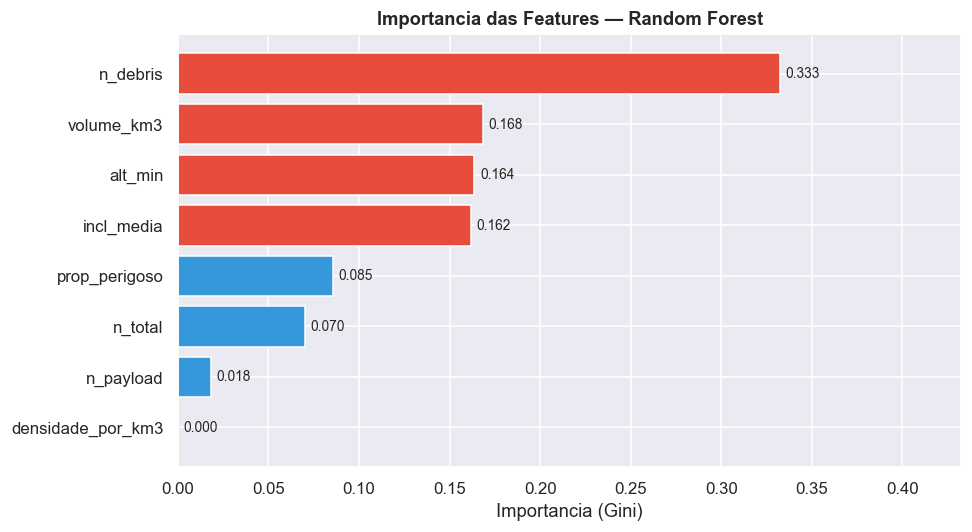

Feature mais importante: n_debris
n_debris             0.3327
volume_km3           0.1683
alt_min              0.1638
incl_media           0.1616
prop_perigoso        0.0854
n_total              0.0699
n_payload            0.0182
densidade_por_km3    0.0000


In [6]:
importancias = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
cores = ['#e74c3c' if v > 0.15 else '#3498db' for v in importancias.values]
bars = ax.barh(importancias.index, importancias.values, color=cores, edgecolor='white')
for bar, val in zip(bars, importancias.values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Importancia das Features — Random Forest', fontweight='bold')
ax.set_xlim(0, importancias.max() + 0.1)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig10_feature_importance.png', bbox_inches='tight')
plt.show()

print('Feature mais importante:', importancias.idxmax())
print(importancias.sort_values(ascending=False).round(4).to_string())

## 3. Modelo B — Projeção Temporal (crescimento de objetos)

Regressão polinomial nos dados históricos para projetar até 2035.

In [7]:
por_ano = (satcat.dropna(subset=['LAUNCH_YEAR'])
           .groupby('LAUNCH_YEAR').size()
           .reset_index(name='novos'))
por_ano['LAUNCH_YEAR'] = por_ano['LAUNCH_YEAR'].astype(int)
por_ano['acumulado'] = por_ano['novos'].cumsum()

treino = por_ano[por_ano['LAUNCH_YEAR'] <= 2025].copy()
treino_recente = por_ano[(por_ano['LAUNCH_YEAR'] >= 2000) & (por_ano['LAUNCH_YEAR'] <= 2025)].copy()

coef = np.polyfit(treino_recente['LAUNCH_YEAR'].values,
                  treino_recente['acumulado'].values, deg=2)
poly = np.poly1d(coef)

anos_proj = np.arange(2000, 2036)
acum_proj = poly(anos_proj)

print('Projecao de objetos acumulados:')
for ano in [2025, 2027, 2030, 2032, 2035]:
    idx = ano - 2000
    print(f'  {ano}: {int(acum_proj[idx]):,} objetos')

Projecao de objetos acumulados:
  2025: 62,539 objetos
  2027: 66,974 objetos
  2030: 74,391 objetos
  2032: 79,846 objetos
  2035: 88,793 objetos


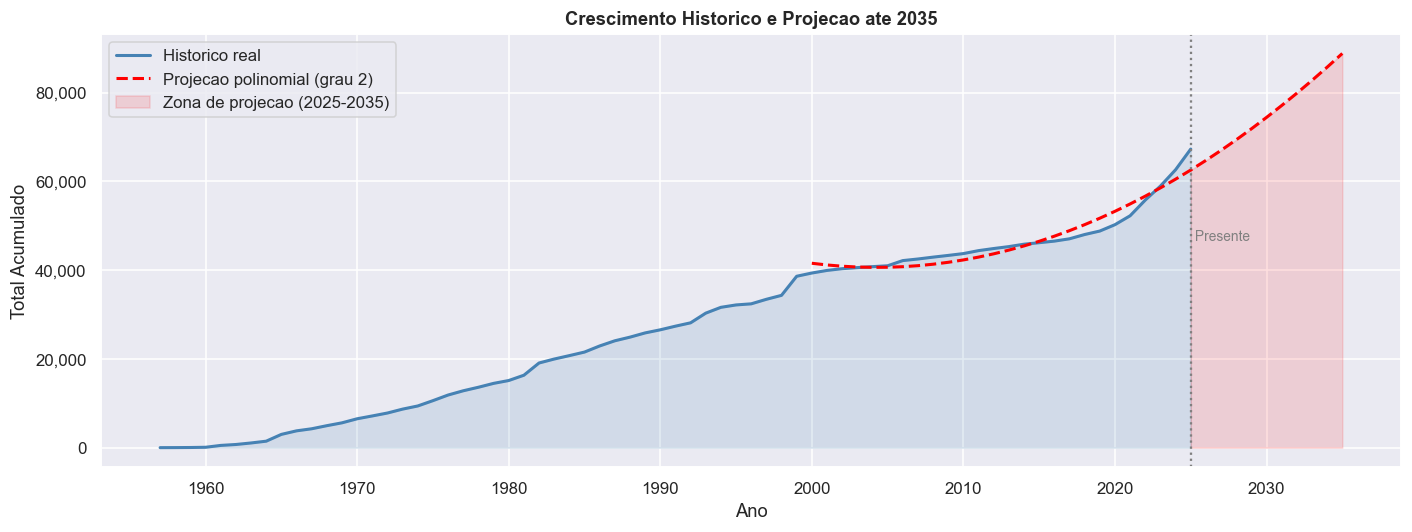

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(treino['LAUNCH_YEAR'], treino['acumulado'],
        color='steelblue', linewidth=2, label='Historico real')
ax.fill_between(treino['LAUNCH_YEAR'], treino['acumulado'], alpha=0.15, color='steelblue')
ax.plot(anos_proj, acum_proj, 'r--', linewidth=2, label='Projecao polinomial (grau 2)')

mask = anos_proj >= 2025
ax.fill_between(anos_proj[mask], acum_proj[mask],
                alpha=0.12, color='red', label='Zona de projecao (2025-2035)')
ax.axvline(2025, color='gray', linestyle=':', linewidth=1.5)
ax.text(2025.3, ax.get_ylim()[1] * 0.5, 'Presente', fontsize=9, color='gray')

ax.set_xlabel('Ano')
ax.set_ylabel('Total Acumulado')
ax.set_title('Crescimento Historico e Projecao ate 2035', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig11_projecao_temporal.png', bbox_inches='tight')
plt.show()

## 4. Projeção de Risco por Faixa até 2035

Combina os dois modelos: cresce os objetos de cada faixa e passa pelo Random Forest para obter o IRR projetado.

In [9]:
total_leo_atual = df['n_total'].sum()
df['fracao_leo'] = df['n_total'] / total_leo_atual
fracao_leo_global = total_leo_atual / treino.iloc[-1]['acumulado']

anos_futuros = list(range(2024, 2036))
total_leo_proj = {ano: fracao_leo_global * poly(ano) for ano in anos_futuros}

registros = []
for ano in anos_futuros:
    fator_global = total_leo_proj[ano] / total_leo_atual
    for _, row in df.iterrows():
        fator = fator_global
        if 400 <= row['alt_min'] < 600:
            fator = fator_global * 1.3   # Starlink cresce mais
        elif 700 <= row['alt_min'] < 1000:
            fator = fator_global * 1.05  # debris cresce mais devagar

        n_total_p   = row['n_total']   * fator
        n_debris_p  = row['n_debris']  * fator
        n_payload_p = row['n_payload'] * fator
        dens_p      = n_total_p / row['volume_km3']
        prop_p      = (row['n_perigoso'] * fator) / max(n_total_p, 1)

        X_p = pd.DataFrame([{
            'alt_min':           row['alt_min'],
            'n_total':           n_total_p,
            'n_debris':          n_debris_p,
            'n_payload':         n_payload_p,
            'prop_perigoso':     prop_p,
            'densidade_por_km3': dens_p,
            'incl_media':        row['incl_media'],
            'volume_km3':        row['volume_km3'],
        }])
        irr_p = float(np.clip(rf.predict(X_p)[0], 0, 10))
        registros.append({'ano': ano, 'faixa': row['FAIXA_ALT'],
                          'alt_min': row['alt_min'], 'IRR_proj': round(irr_p, 3),
                          'n_total': int(n_total_p)})

df_proj = pd.DataFrame(registros)
print(f'Projecoes geradas: {len(df_proj)} registros')
print(df_proj[df_proj['faixa'].isin(['400-500','800-900'])].sort_values(['faixa','ano']).to_string(index=False))

Projecoes geradas: 216 registros
 ano   faixa  alt_min  IRR_proj  n_total
2024 400-500      400     4.372     8643
2025 400-500      400     4.372     8938
2026 400-500      400     4.372     9248
2027 400-500      400     4.372     9572
2028 400-500      400     4.372     9911
2029 400-500      400     4.372    10264
2030 400-500      400     4.372    10632
2031 400-500      400     4.372    11015
2032 400-500      400     4.372    11412
2033 400-500      400     4.372    11823
2034 400-500      400     4.372    12250
2035 400-500      400     4.372    12691
2024 800-900      800     6.392     2833
2025 800-900      800     6.436     2929
2026 800-900      800     6.436     3031
2027 800-900      800     6.436     3137
2028 800-900      800     6.436     3248
2029 800-900      800     6.436     3364
2030 800-900      800     6.436     3485
2031 800-900      800     6.436     3610
2032 800-900      800     6.436     3740
2033 800-900      800     6.436     3875
2034 800-900      800   

## 5. Visualização: Risco Projetado 2024–2035

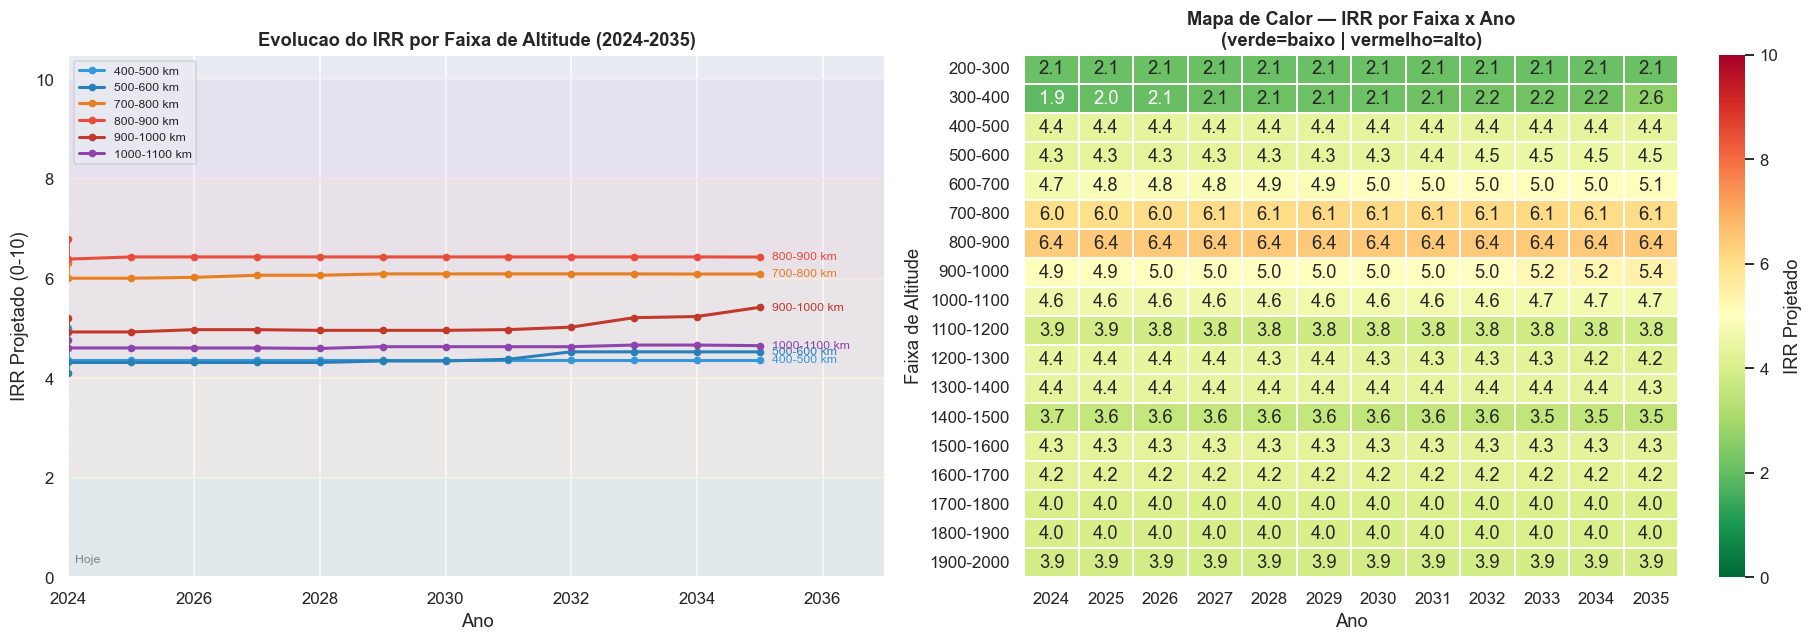

Salvo: outputs/fig12_risco_projetado.png


In [10]:
faixas_destaque = ['400-500', '500-600', '700-800', '800-900', '900-1000', '1000-1100']
cores_faixas = {
    '400-500': '#3498db', '500-600': '#2980b9',
    '700-800': '#e67e22', '800-900': '#e74c3c',
    '900-1000': '#c0392b', '1000-1100': '#8e44ad',
}

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Linhas de evolucao por faixa
for faixa in faixas_destaque:
    sub = df_proj[df_proj['faixa'] == faixa].sort_values('ano')
    if len(sub) == 0:
        continue
    irr_atual_vals = df.loc[df['FAIXA_ALT'] == faixa, 'IRR'].values
    if len(irr_atual_vals) == 0:
        continue
    irr_atual = float(irr_atual_vals[0])
    anos_plot = [2024] + sub['ano'].tolist()
    irr_plot  = [irr_atual] + sub['IRR_proj'].tolist()
    cor = cores_faixas.get(faixa, 'gray')
    axes[0].plot(anos_plot, irr_plot, marker='o', markersize=4,
                 linewidth=2, color=cor, label=f'{faixa} km')
    axes[0].annotate(f'{faixa} km', xy=(2035, irr_plot[-1]),
                     xytext=(2035.2, irr_plot[-1]),
                     fontsize=8, color=cor, va='center')

axes[0].axvline(2024, color='gray', linestyle=':', linewidth=1.2)
axes[0].text(2024.1, 0.3, 'Hoje', fontsize=8, color='gray')
for y0, y1, cor in [(0,2,'#2ecc71'),(2,4,'#f1c40f'),(4,6,'#e67e22'),(6,8,'#e74c3c'),(8,10,'#8e44ad')]:
    axes[0].axhspan(y0, y1, alpha=0.05, color=cor)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('IRR Projetado (0-10)')
axes[0].set_title('Evolucao do IRR por Faixa de Altitude (2024-2035)', fontweight='bold')
axes[0].set_xlim(2024, 2037)
axes[0].set_ylim(0, 10.5)
axes[0].legend(loc='upper left', fontsize=8)

# Heatmap
pivot = df_proj.pivot_table(index='faixa', columns='ano', values='IRR_proj')
pivot['_sort'] = pivot.index.map(lambda f: int(str(f).split('-')[0]) if '-' in str(f) else 999)
pivot = pivot.sort_values('_sort').drop(columns='_sort')

sns.heatmap(pivot, ax=axes[1], cmap='RdYlGn_r', vmin=0, vmax=10,
            annot=True, fmt='.1f', linewidths=0.3,
            cbar_kws={'label': 'IRR Projetado'})
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Faixa de Altitude')
axes[1].set_title('Mapa de Calor — IRR por Faixa x Ano\n(verde=baixo | vermelho=alto)', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig12_risco_projetado.png', bbox_inches='tight')
plt.show()
print('Salvo: outputs/fig12_risco_projetado.png')

## 6. Salvar Resultados

In [11]:
df_proj.to_csv(PROC_DIR / 'irr_projetado_2024_2035.csv', index=False)
joblib.dump(rf, PROC_DIR / 'modelo_rf_irr.pkl')
print('Salvo: data/processed/irr_projetado_2024_2035.csv')
print('Salvo: data/processed/modelo_rf_irr.pkl')

Salvo: data/processed/irr_projetado_2024_2035.csv
Salvo: data/processed/modelo_rf_irr.pkl


## 7. Resumo Final

In [12]:
print('=' * 65)
print('  RESUMO FINAL DO MODELO ML')
print('=' * 65)
print()
print('Validacao (LOO-CV):')
for nome, res in resultados.items():
    print(f'  {nome:25s}: RMSE={res["RMSE"]:.3f}  R2={res["R2"]:.3f}')

print()
print('Feature mais importante:', importancias.idxmax())

print()
print('Faixa com maior IRR atual:')
top1 = df.nlargest(1, 'IRR')[['FAIXA_ALT','IRR','NIVEL_RISCO','n_total','n_debris']]
print(top1.to_string(index=False))

print()
print('Faixa com maior IRR projetado em 2035:')
top35 = df_proj[df_proj['ano'] == 2035].nlargest(1, 'IRR_proj')[['faixa','IRR_proj','n_total']]
print(top35.to_string(index=False))

print()
print('Arquivos gerados:')
for f in ['features_risco_leo.csv', 'irr_projetado_2024_2035.csv', 'modelo_rf_irr.pkl']:
    print(f'  data/processed/{f}')
for f in ['fig09_real_vs_previsto.png', 'fig10_feature_importance.png',
          'fig11_projecao_temporal.png', 'fig12_risco_projetado.png']:
    print(f'  outputs/{f}')
print()
print('Proximo passo: Dashboard (Streamlit)')
print('=' * 65)

  RESUMO FINAL DO MODELO ML

Validacao (LOO-CV):
  Random Forest            : RMSE=0.722  R2=nan
  Gradient Boosting        : RMSE=0.544  R2=nan
  Regressao Linear         : RMSE=0.033  R2=nan

Feature mais importante: n_debris

Faixa com maior IRR atual:
FAIXA_ALT  IRR NIVEL_RISCO  n_total  n_debris
  800-900  6.8        ALTO     3001      2547

Faixa com maior IRR projetado em 2035:
  faixa  IRR_proj  n_total
800-900     6.433     4159

Arquivos gerados:
  data/processed/features_risco_leo.csv
  data/processed/irr_projetado_2024_2035.csv
  data/processed/modelo_rf_irr.pkl
  outputs/fig09_real_vs_previsto.png
  outputs/fig10_feature_importance.png
  outputs/fig11_projecao_temporal.png
  outputs/fig12_risco_projetado.png

Proximo passo: Dashboard (Streamlit)
